In [93]:
import pandas as pd
import numpy as np


In [94]:
df = pd.read_csv('/content/sample_data/homeprices.csv')

In [96]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [102]:
import math
median_bedrooms = math.floor(df.bedrooms.median())
median_bedrooms

4

In [105]:
df.bedrooms = df.bedrooms.fillna(median_bedrooms)
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [106]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [107]:
reg.fit(df[['area', 'bedrooms', 'age']], df.price)

LinearRegression()

In [109]:
 reg.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [111]:
reg.intercept_

np.float64(221323.00186540396)

In [117]:
reg.predict([[3000,3,40]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

How it is calculated

In [119]:
112.06244194*3000 + 23388.88007794*3 + -3231.71790863*40 + 221323.00186540396

498408.251574024

In [121]:
reg.predict([[3000,3,10]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([595359.7888393])

# KNN Classification


In [124]:
from sklearn.datasets import load_iris
iris = load_iris()

In [125]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [126]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [127]:
df1 = pd.DataFrame(iris.data, columns=iris.feature_names)
df1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [128]:
df1['target'] = iris.target
df1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [129]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [130]:
df1['flower_name'] = df1.target.apply(lambda x: iris.target_names[x])
df1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [131]:
df0 = df1[df1.target==1]
df11 = df1[df1.target==2]
df2 = df1[df1.target==3]

Text(0, 0.5, 'sepal width')

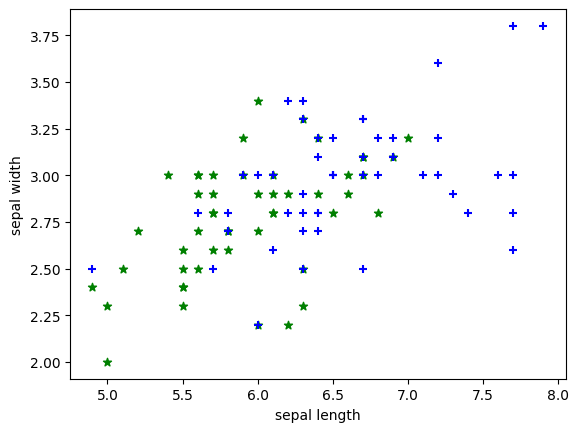

In [132]:
import matplotlib.pyplot as plt

plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], marker='*',color='green')
plt.scatter(df11['sepal length (cm)'], df11['sepal width (cm)'], marker='+',color='blue')
plt.xlabel('sepal length')
plt.ylabel('sepal width')

Text(0, 0.5, 'petal width')

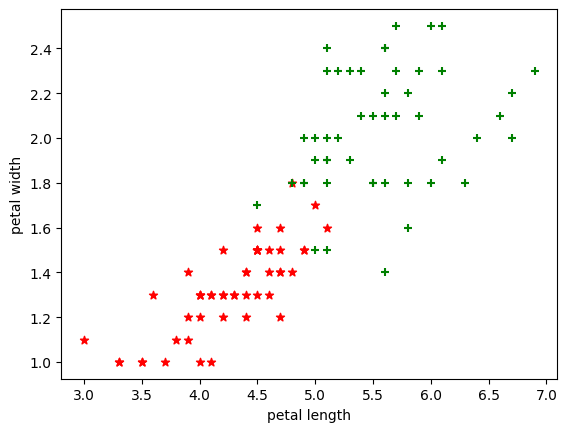

In [133]:
plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'], marker='*',color='red')
plt.scatter(df11['petal length (cm)'], df11['petal width (cm)'], marker='+',color='green')
plt.xlabel('petal length')
plt.ylabel('petal width')

In [134]:
from sklearn.model_selection import train_test_split

X = df1.drop(['target','flower_name'], axis='columns')
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [135]:
y = df1.target

In [136]:
y.shape

(150,)

In [149]:
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2)

In [150]:
len(X_train)

120

In [151]:
len(X_test)

30

In [152]:
from sklearn.neighbors import KNeighborsClassifier

In [156]:
knn = KNeighborsClassifier(n_neighbors=3)

In [157]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [158]:
knn.score(X_test, y_test)

0.9666666666666667

In [159]:
from sklearn.metrics import confusion_matrix

In [160]:
y_pred = knn.predict(X_test)

In [161]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[15,  0,  0],
       [ 0,  7,  1],
       [ 0,  0,  7]])

In [163]:
import seaborn as sn

Text(58.222222222222214, 0.5, 'Truth')

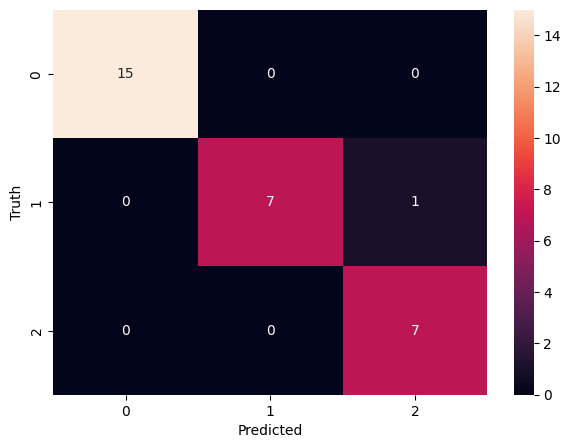

In [164]:
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [166]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.88      0.93         8
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

